In [12]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [13]:
# Criando a series a partir da api do kaggle
# chamei DF, mas é uma SERIES!
def kaggle_para_df(caminho="", nome=""):
    df = kagglehub.dataset_load(
        KaggleDatasetAdapter.PANDAS,
        nome,
        caminho,
    )
    return df


df = kaggle_para_df(
    "Salary_Data.csv", "rohankayan/years-of-experience-and-salary-dataset"
)


In [14]:
# Verificando a importação
df.head()

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0


In [15]:
# Conhecendo os dados
df.describe()

,YearsExperience,Salary
count,30.000000,30.000000
mean,5.313333,76003.000000
std,2.837888,27414.429785
min,1.100000,37731.000000
25%,3.200000,56720.750000
50%,4.700000,65237.000000
75%,7.700000,100544.750000
max,10.500000,122391.000000


In [16]:
# Separando os parâmetros e conjuntos
X = df[["YearsExperience"]]
y = df["Salary"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
# Criando o modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
# Criando a predição
y_pred = modelo.predict(X_test)

In [19]:
# Criando métricas de desempenho
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)


In [20]:
# Exibindo as métricas
print(f"Coeficiente (inclinação): {modelo.coef_[0]:,.2f}")
print(f"Intercepto:               {modelo.intercept_:,.2f}")
print(f"R²:                       {r2:.4f}")
print(f"RMSE:                     {rmse:,.2f}")

Coeficiente (inclinação): 9,423.82
Intercepto:               25,321.58
R²:                       0.9024
RMSE:                     7,059.04


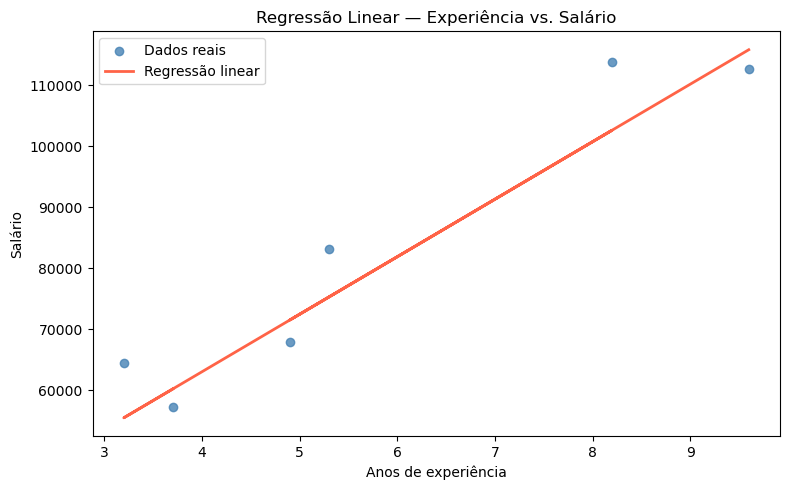

In [21]:
# Plotando as informações e a regressão
plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color="steelblue", label="Dados reais", alpha=0.8)
plt.plot(X_test, y_pred, color="tomato", linewidth=2, label="Regressão linear")
plt.xlabel("Anos de experiência")
plt.ylabel("Salário")
plt.title("Regressão Linear — Experiência vs. Salário")
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
# Criando função para prever o salário a partir da experiência
def previsao(anos=0):
    salario = modelo.predict(
        pd.DataFrame([[anos]], columns=["YearsExperience"])
    )
    valor = salario[0]

    return f"Salário previsto para {anos} anos de experiência: ${valor:,.2f}"


previsao(7)

'Salário previsto para 7 anos de experiência: $91,288.29'